In [66]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/mdismielhossenabir/sentiment-analysis/sentiment_analysis.csv


In [67]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [68]:
df=pd.read_csv('/kaggle/input/datasets/mdismielhossenabir/sentiment-analysis/sentiment_analysis.csv')
df.head()

,Year,Month,Day,Time of Tweet,text,sentiment,Platform
0,2018,8,18,morning,What a great day!!! Looks like dream.,positive,Twitter
1,2018,8,18,noon,"I feel sorry, I miss you here in the sea beach",positive,Facebook
2,2017,8,18,night,Don't angry me,negative,Facebook
3,2022,6,8,morning,We attend in the class just for listening teac...,negative,Facebook
4,2022,6,8,noon,"Those who want to go, let them go",negative,Instagram


In [69]:
df.shape

(499, 7)

In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 499 entries, 0 to 498
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Year           499 non-null    int64 
 1   Month          499 non-null    int64 
 2   Day            499 non-null    int64 
 3   Time of Tweet  499 non-null    object
 4   text           499 non-null    object
 5   sentiment      499 non-null    object
 6   Platform       499 non-null    object
dtypes: int64(3), object(4)
memory usage: 27.4+ KB


In [71]:
df.isnull().sum()

Year             0
Month            0
Day              0
Time of Tweet    0
text             0
sentiment        0
Platform         0
dtype: int64

In [72]:
df['sentiment'].value_counts()

sentiment
neutral     199
positive    166
negative    134
Name: count, dtype: int64

Observation:
The dataset contains text data collected from different social media platforms.
The target variable is sentiment with positive and negative classes.

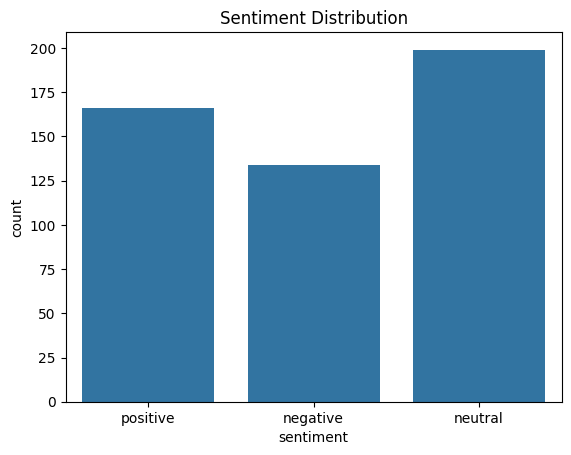

In [73]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='sentiment', data=df)

plt.title("Sentiment Distribution")

plt.show()

Observation: Positive and negative sentiments are distributed across the dataset.

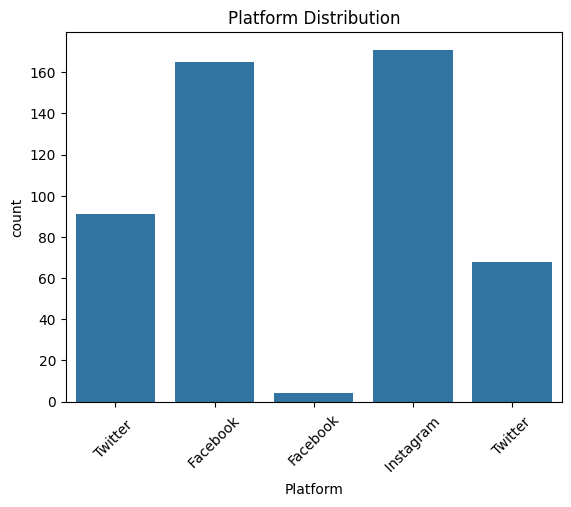

In [74]:
sns.countplot(x='Platform', data=df)

plt.title("Platform Distribution")

plt.xticks(rotation=45)

plt.show()

Observation: The dataset contains tweets/posts from multiple social media platforms.

In [75]:
X = df['text']

y = df['sentiment']

In [76]:
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)
X = tfidf.fit_transform(X)

In [86]:
le = LabelEncoder()
y = le.fit_transform(df['sentiment'])

In [87]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [88]:
model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

In [89]:
pred = model.predict(X_test)

In [90]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, pred)

print("Accuracy:", accuracy)

Accuracy: 0.62


In [91]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       1.00      0.28      0.43        36
           1       0.46      0.93      0.62        30
           2       0.83      0.71      0.76        34

    accuracy                           0.62       100
   macro avg       0.76      0.64      0.60       100
weighted avg       0.78      0.62      0.60       100



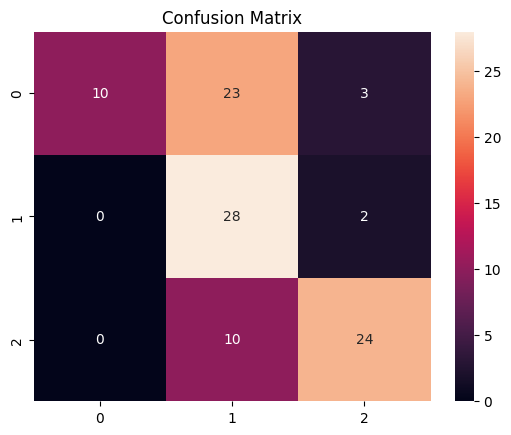

In [92]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")

plt.show()

In [93]:
sample = ["This product is amazing and I love it"]

sample_vector = tfidf.transform(sample)

prediction = model.predict(sample_vector)

print(le.inverse_transform(prediction))

['positive']


In [98]:
sample = ["Not Bad. Somewhat ok"]

sample_vector = tfidf.transform(sample)

prediction = model.predict(sample_vector)

print(le.inverse_transform(prediction))

['neutral']


**Conclusion**

1. Text data was converted into numerical features using TF-IDF.
2. Label Encoding was applied to sentiment labels.
3. Multinomial Naive Bayes was used for sentiment classification.
4. The model successfully classified positive and negative sentiments.
5. Sentiment Analysis can help understand public opinion from social media data.